# Experiment 5 — GPS positioning & trajectory forecast (maneuvering object)

Real-time smoothing and short-horizon forecasting of a **maneuvering** object's position
stream. A standard multilateration front end (`scipy.least_squares`) produces noisy fixes
from satellite pseudoranges; dtfit's online filter then tracks the trajectory with a
**generic constant-acceleration model** (it is *not* given the maneuver), compared on equal
footing to the gold-standard CA Kalman. This is the honest, realistic test — an earlier
version handed dtfit the exact generating functions and so overstated its advantage; here
the maneuver (changing heading/speed/climb) is unknown to both.

A GNSS receiver computes its position by multilateration from several satellite pseudoranges;
a *moving* receiver produces a stream of noisy position fixes. The temporal smoothing and
short-horizon forecasting of that stream is dtfit's actual domain (bounded-cost online
tracking of a nonlinear time signal).

This version is deliberately **realistic and honest**: the object flies a genuinely
*maneuvering* trajectory — a sequence of coordinated turns with **changing heading, speed and
climb rate** (piecewise-constant turn rate / speed / vertical rate, integrated into position),
so there is **no closed-form per-axis function** to recover. dtfit is therefore *not* handed
the generating model; instead each axis is tracked online by a **generic local model** (a
constant-acceleration quadratic over a short sliding window) with drift detection that re-arms
the filter at each maneuver. It is compared on equal footing to the gold-standard
constant-acceleration **Kalman filter** — same information class, no structural advantage
given to either.

1. **Front end (standard method)**: satellites at known positions, the object on the
   maneuvering trajectory, noisy pseudoranges, instantaneous fix by multilateration
   (`scipy.optimize.least_squares`) — dtfit is *not* a multilateration solver.
2. **dtfit role**: a per-satellite `FilterBank` (the documented negative) and a per-axis
   generic-model bank that smooths, forecasts, and flags maneuver onsets online.

Note this experiment does *not* exercise the joint shared-parameter fit (#4): the axes share
no parameter, so there is nothing to couple — #4's weak-data retest remains open.

All heavy logic lives in `backend.py` (`B.*`), so this notebook is a thin, rerunnable
presentation layer over the exact simulation + estimation code.

## Setup
Imports, configuration, and small helpers. Re-run after changing the config.

In [1]:
import importlib
from pathlib import Path
import numpy as np
import pandas as pd

# The package name starts with a digit, so a normal `from ... import backend`
# is not valid syntax -- import the backend (single source of truth for the
# simulation + estimators) via importlib.
B = importlib.import_module("dtfit_experimental.experiments.cases.05_gps_trajectory.backend")
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)

FIG = Path(B.__file__).parent / "figures"          # a saved copy of every figure
FIG.mkdir(exist_ok=True)

# ---- configuration (edit + re-run) ----------------------------------------- #
# Defaults are the old `quick=True` reductions so the notebook runs in a couple
# of minutes. Scale up to the full run with N = 400 and N_SEEDS = 12.
N        = 240                     # GPS epochs over the 12 s flight (full: 400)
N_SEEDS  = 4                       # independent noise realizations (full: 12)
HZ       = [1, 3, 5, 8, 12, 16, 20, 25]   # rolling-forecast horizons (steps ahead)
H_TABLE  = [1, 5, 20]              # horizons shown in the forecast table

WARMUP   = B.WARMUP                # skip the fill-window transient when scoring
INFLATE  = B.INFLATE

pd.set_option("display.float_format", lambda v: f"{v:.3f}")
print(f"flight 12s | {N} epochs | {B.SATS.shape[0]} satellites | "
      f"maneuver onsets t={B.MANEUVER_ONSETS} | {N_SEEDS} noise realizations")
print(f"figures saved to: {FIG}")

flight 12s | 240 epochs | 6 satellites | maneuver onsets t=[3.0, 6.0, 9.0] | 4 noise realizations
figures saved to: F:\repos\fallen-traces\science-nonline\packages\dtfit-experimental\src\dtfit_experimental\experiments\cases\05_gps_trajectory\figures


## Models fitted & why

The object **maneuvers**: heading, speed and climb rate change at `t = 3, 6, 9` (a left turn,
then accelerate + level, then a hard right turn while descending). There is **no closed-form
per-axis function**, so neither estimator is handed the answer:

- **dtfit (generic):** each axis is tracked online by a local **constant-acceleration
  quadratic** `c0 + c1·t + c2·t²` over a short (15-sample) sliding window. Tested with **both**
  streaming measurements: **EAC** (`EACFilter`, area) and **LSI** (`LSIFilter`, orthogonal
  Legendre spectrum, order 3). *Plain* uses each filter's built-in per-axis detector; *fused*
  (the improvement below) instead detects maneuvers from the **joint** innovation of all three
  axes and re-arms them together. The `p0` is taken from the first fix (no truth used).
- **Kalman (CA):** the standard constant-acceleration filter — the **same information class**.
  Run two ways: *fixed* (the textbook tuning) and *adaptive* (the **identical**
  fused-innovation re-arming applied to the baseline, so dtfit gets no free adaptive advantage).
- **Per-satellite range smoothing:** `ρ = a + b·t` (the negative-result front end — see below).

All accuracy numbers are **means over multiple independent noise realizations** (a single seed
proved unrepresentative). The questions: is dtfit *competitive* with the gold-standard Kalman
on a genuinely maneuvering target, can a better detector recover the maneuvers the original
missed, and does acting on detection actually improve tracking?

## Front end — multilateration fixes & per-satellite smoothing (adaptation)

The seed-0 scenario drives the figures; metrics in the later sections are averaged over
`N_SEEDS` noise realizations of the same flight. The natural-looking 'EAC per satellite
stream' architecture — a `FilterBank` smoothing each pseudorange stream independently
*before* multilateration — instead **degrades** the fix. This is an instructive negative
result: multilateration needs the satellite ranges at a single instant to be mutually
*consistent*, and smoothing each stream independently (each with its own lag) breaks that
synchrony, so the geometry solve diverges. The lesson — borne out by the next section — is
that dtfit smoothing belongs at the **trajectory (position) level**, not on the raw
per-satellite ranges.

In [2]:
# seed 0 drives the figures; metrics below are averaged over N_SEEDS realizations
t, truth, rho, fixes = B.build_scenario(N, seed=0)
sl = slice(WARMUP, N)
dt_smooth, _, dt_drifts = B.dtfit_eval(t, fixes, HZ, fused=True)
kf_smooth, _, _ = B.kalman_eval(t, fixes, HZ, q=5e-2, adaptive=False)

raw_fix_rmse = B.rmse3(fixes[sl], truth[sl])
fixes_smoothed = B.per_satellite_smoothing(t, rho)
sat_fix_rmse = B.rmse3(fixes_smoothed[sl], truth[sl])

front_end = pd.DataFrame(
    {"raw per-epoch multilateration fix": {"position RMSE (km)": raw_fix_rmse},
     "EAC per-satellite smoothing (negative)": {"position RMSE (km)": sat_fix_rmse}}).T
front_end

,position RMSE (km)
raw per-epoch multilateration fix,3.231
EAC per-satellite smoothing (negative),3.821


## In-track smoothing (mean position RMSE over realizations)

Filtered estimate vs truth over the maneuvering flight (warm-up excluded), averaged over
`N_SEEDS` noise realizations. The block below also collects the rolling-forecast errors and
maneuver-onset detection counts used by the next two sections.

In [3]:
labels = ["raw fixes", "dtfit (EAC, plain)", "dtfit (EAC, fused)",
          "dtfit (LSI, fused)", "Kalman (fixed)", "Kalman (adaptive)"]
sm = {lb: [] for lb in labels}
fcr = {lb: {h: [] for h in HZ} for lb in labels if lb != "raw fixes"}
det_labels = ["dtfit (EAC, plain)", "dtfit (EAC, fused)",
              "dtfit (LSI, fused)", "Kalman (adaptive)"]
det_c = {lb: [] for lb in det_labels}
det_f = {lb: [] for lb in det_labels}
rw_fc = {h: [] for h in HZ}

for seed in range(N_SEEDS):
    ts, trs, _, fxs = B.build_scenario(N, seed=seed)
    slc = slice(WARMUP, N)
    runs = {
        "dtfit (EAC, plain)": B.dtfit_eval(ts, fxs, HZ, kind="eac", fused=False),
        "dtfit (EAC, fused)": B.dtfit_eval(ts, fxs, HZ, kind="eac", fused=True),
        "dtfit (LSI, fused)": B.dtfit_eval(ts, fxs, HZ, kind="lsi", fused=True),
        "Kalman (fixed)": (*B.kalman_eval(ts, fxs, HZ, q=5e-2, adaptive=False)[:2], []),
        "Kalman (adaptive)": B.kalman_eval(ts, fxs, HZ, q=5e-2, adaptive=True),
    }
    sm["raw fixes"].append(B.rmse3(fxs[slc], trs[slc]))
    for lb, (sm_arr, pr, dr) in runs.items():
        sm[lb].append(B.rmse3(sm_arr[slc], trs[slc]))
        for h in HZ:
            fcr[lb][h].append(B.roll_rmse(pr[h], trs))
        if lb in det_c:
            c, f = B.match_onsets(dr)
            det_c[lb].append(c)
            det_f[lb].append(f)
    rw_seed = B.rw_pred(fxs, HZ)
    for h in HZ:
        rw_fc[h].append(B.roll_rmse(rw_seed[h], trs))

smm = {lb: float(np.mean(v)) for lb, v in sm.items()}
fcm = {lb: {h: float(np.mean(fcr[lb][h])) for h in HZ} for lb in fcr}
rwm = {h: float(np.mean(rw_fc[h])) for h in HZ}

E_smooth = pd.DataFrame({lb: {"position RMSE (km)": smm[lb]} for lb in labels}).T
E_smooth

,position RMSE (km)
raw fixes,3.406
"dtfit (EAC, plain)",1.775
"dtfit (EAC, fused)",1.606
"dtfit (LSI, fused)",1.682
Kalman (fixed),1.424
Kalman (adaptive),1.449


## Rolling short-horizon forecast (mean over realizations)

At every step, predict `h` steps ahead and score against truth, averaged over the whole flight
and over realizations. A single long extrapolation is *not* used — no constant-acceleration
model can forecast through an unobserved future turn.

In [4]:
fc_methods = ["dtfit (EAC, plain)", "dtfit (EAC, fused)", "dtfit (LSI, fused)",
              "Kalman (fixed)", "Kalman (adaptive)"]
E_forecast = pd.DataFrame(
    {lb: {f"h={h} (km)": fcm[lb][h] for h in H_TABLE} for lb in fc_methods}).T
E_forecast

,h=1 (km),h=5 (km),h=20 (km)
"dtfit (EAC, plain)",1.982,2.932,7.938
"dtfit (EAC, fused)",1.771,2.595,7.451
"dtfit (LSI, fused)",1.874,2.804,8.207
Kalman (fixed),1.545,2.173,6.380
Kalman (adaptive),1.571,2.215,6.467


## Maneuver-onset detection — the fused detector (improvement)

True onsets at `t = [3.0, 6.0, 9.0]`. The original per-axis area-innovation detector caught
few onsets on average; the **fused** detector — which forms a single χ²(3) statistic from all
three axes' one-step forecast residuals and runs a CUSUM on it — catches **roughly double**.
*Why fusion is the fix:* a coordinated turn moves several axes at once, so per axis the onset
is only ~1.4–3.2× the baseline noise (and the z-axis with the largest peak also has the largest
noise, so a per-axis detector is unreliable), but **fused the maneuver reaches ~4× and is
consistent across all three onsets**. The integrated full-window *area* statistic the original
watched additionally smooths the brief onset transient away; the per-sample forecast residual
does not. **The first onset (t=3) stays hard** — it sits on the filter's own convergence
transient, an honest startup/SNR limit. The **LSI** filter with the same fused detector is on
par with EAC (its richer spectral innovation has no extra maneuver signature to offer on this
low-order trend).

In [5]:
E_detect = pd.DataFrame(
    {lb: {"onsets caught (of 3)": float(np.mean(det_c[lb])),
          "false alarms": float(np.mean(det_f[lb]))} for lb in det_labels}).T
E_detect

,onsets caught (of 3),false alarms
"dtfit (EAC, plain)",0.500,0.500
"dtfit (EAC, fused)",1.500,1.000
"dtfit (LSI, fused)",1.750,0.750
Kalman (adaptive),1.750,1.500


## Figures — trajectory & ground track

Maneuvering trajectory (seed 0): truth vs raw fixes vs dtfit (EAC, fused) vs Kalman; red ×
mark the fused-detector maneuver flags on the horizontal ground track.

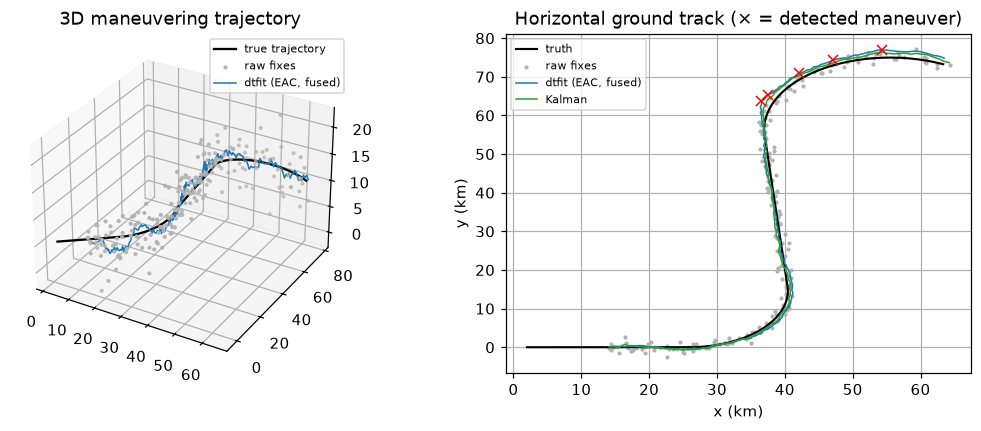

In [6]:
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot(*truth.T, "k", lw=1.5, label="true trajectory")
ax.scatter(*fixes[sl].T, s=3, c="0.7", label="raw fixes")
ax.plot(*dt_smooth[sl].T, "tab:blue", lw=1.0, label="dtfit (EAC, fused)")
ax.set_title("3D maneuvering trajectory")
ax.legend(fontsize=7)

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(truth[:, 0], truth[:, 1], "k", lw=1.4, label="truth")
ax2.scatter(fixes[sl, 0], fixes[sl, 1], s=3, c="0.7", label="raw fixes")
ax2.plot(dt_smooth[sl, 0], dt_smooth[sl, 1], "tab:blue", lw=1.0, label="dtfit (EAC, fused)")
ax2.plot(kf_smooth[sl, 0], kf_smooth[sl, 1], "tab:green", lw=1.0, label="Kalman")
for d in dt_drifts:  # mark detected maneuvers on the ground track
    k = int(np.argmin(np.abs(t - d)))
    ax2.plot(dt_smooth[k, 0], dt_smooth[k, 1], "rx", ms=7)
ax2.set_title("Horizontal ground track (× = detected maneuver)")
ax2.set_xlabel("x (km)"); ax2.set_ylabel("y (km)"); ax2.legend(fontsize=7)
fig.savefig(FIG / "trajectory.png", dpi=110, bbox_inches="tight")
plt.show()

Rolling h-step forecast error, averaged over the flight and over noise realizations.

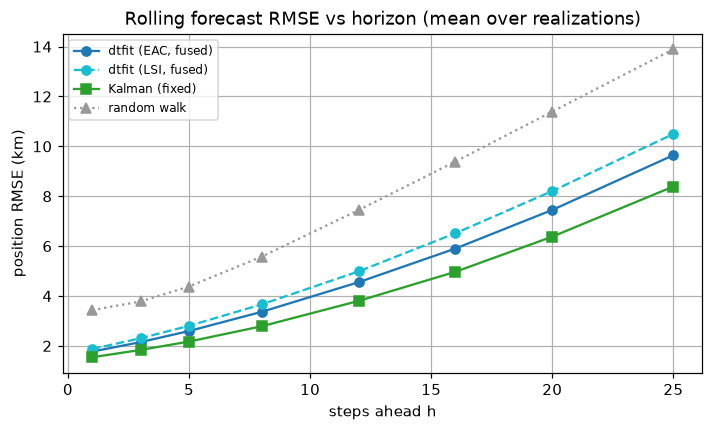

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(HZ, [fcm["dtfit (EAC, fused)"][h] for h in HZ], "o-", color="tab:blue",
        label="dtfit (EAC, fused)")
ax.plot(HZ, [fcm["dtfit (LSI, fused)"][h] for h in HZ], "o--", color="tab:cyan",
        label="dtfit (LSI, fused)")
ax.plot(HZ, [fcm["Kalman (fixed)"][h] for h in HZ], "s-", color="tab:green",
        label="Kalman (fixed)")
ax.plot(HZ, [rwm[h] for h in HZ], "^:", color="0.6", label="random walk")
ax.set_title("Rolling forecast RMSE vs horizon (mean over realizations)")
ax.set_xlabel("steps ahead h"); ax.set_ylabel("position RMSE (km)")
ax.legend(fontsize=8)
fig.savefig(FIG / "forecast_horizon.png", dpi=110, bbox_inches="tight")
plt.show()

## Reading it

- **In-track smoothing.** Both estimators roughly halve the raw-fix error. dtfit's
  fused-adaptive EAC filter **improves on plain EAC** and narrows the gap to the Kalman, but
  does not overtake it (best is typically the fixed Kalman).
- **EAC vs LSI — the two streaming measurements are essentially tied here** (smoothing and
  h=5 forecast). The Legendre spectrum's advantage is resolving *frequency / phase / shape*
  (coupled, oscillatory models); a constant-acceleration **quadratic over a short window has
  no such structure**, so the area measurement already captures it and the richer spectral
  measurement buys nothing — it would shine on an oscillatory target (cf. the control-ID and
  seasonal experiments), not a smooth trajectory.
- **Short-horizon forecast.** Same ordering: dtfit (EAC, fused) beats plain EAC but trails
  Kalman (fixed); the gap stays small across horizons.
- **The fused detector is a real improvement (the headline).** It roughly doubles maneuver
  detection by exploiting that a maneuver moves all axes at once — the mechanistically right
  fix for the blindness the original per-axis area detector showed (it caught ~none).
- **But acting on detection has a narrow useful regime.** A *gentle* covariance nudge
  (×{INFLATE}) on a flag turns the better detection into a small tracking gain for dtfit —
  because plain dtfit is slightly *under*-reactive and has headroom. The **same** nudge
  slightly *hurts* the Kalman (same machinery): it is already near-optimal, so any extra
  inflation adds variance. Aggressive re-arming (×100, tested) hurts both.
- **The ceiling is measurement SNR, not the algorithm.** These acceleration-level maneuvers
  sit barely above the ~3 km fix noise, so neither sharper detection nor adaptation overtakes
  the fixed Kalman, and the adaptive Kalman cannot beat the fixed one. Reliable maneuver
  detection from position alone is near the information limit — real systems fuse an
  independent sensor (an IMU/gyro), where the maneuver is obvious in acceleration but buried
  in position.
- **The earlier 22× 'win' was an artifact** of handing dtfit the exact generating functions
  (linear/sine/exponential); with a realistic unknown maneuver and a generic model the gap
  vanishes — dtfit's structural-model advantage is real **only when the model is genuinely
  known** (see Exp 1).
- Architecture notes: the per-satellite `FilterBank` above is a documented negative (it breaks
  multilateration consistency); the joint fit (#4) is *not* exercised here. The fused detector
  is built on two library primitives (`EACFilter.last_residual_` and `.inflate()`); the
  multilateration front end is standard `scipy.least_squares`.